In [2]:
import pandas as pd

# Load the file with the exact name from your screenshot
df = pd.read_csv('Processed_Reviews (1).csv')

# Step 3: Use only the lemmatized column and the label you created [cite: 171, 173]
# We drop rows that don't have a label or text to avoid errors
df = df.dropna(subset=['lemmatized', 'label'])

# Ensure labels are integers (0 or 1) [cite: 174]
df['label'] = df['label'].astype(int)

print("Data Loaded! Here are the first few rows:")
df[['lemmatized', 'label']].head()

Data Loaded! Here are the first few rows:


,lemmatized,label
0,product arrive time packaging great quality am...,1
1,product amaze love,1
2,buy phone hz display totally worth,1
3,wow product awesome bit expensive,0
4,laptop work perfectly fine,1


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 4: Apply TfidfVectorizer 
tfidf_vect = TfidfVectorizer()
X = tfidf_vect.fit_transform(df['lemmatized'])
y = df['label']

print(f"Vectorization complete. Feature matrix shape: {X.shape}")

Vectorization complete. Feature matrix shape: (13, 53)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

# Step 5: Split the data (75% train, 25% test) [cite: 178, 179]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train Naïve Bayes [cite: 181]
nb_clf = MultinomialNB().fit(X_train, y_train)

# Train SVM [cite: 181]
svm_clf = SVC(kernel='linear').fit(X_train, y_train)

print("Models trained: Naïve Bayes and SVM are ready.")

Models trained: Naïve Bayes and SVM are ready.


Matplotlib is building the font cache; this may take a moment.


--- Naïve Bayes Report ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


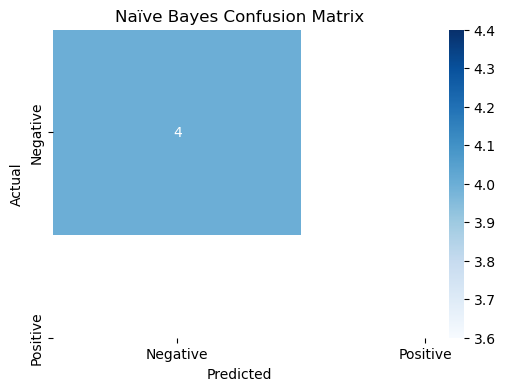

--- SVM Report ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


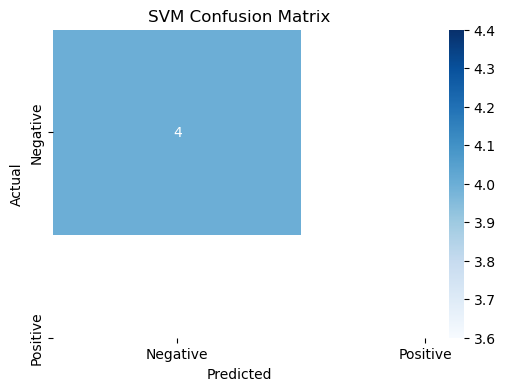

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 6: Evaluation [cite: 182]
def evaluate_model(model, model_name):
    predictions = model.predict(X_test)
    print(f"--- {model_name} Report ---")
    # Display accuracy, precision, recall, and F1-score [cite: 183]
    print(classification_report(y_test, predictions))
    
    # Optional: Display the confusion matrix [cite: 183]
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Positive'], 
                yticklabels=['Negative', 'Positive'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Run evaluation for both models
evaluate_model(nb_clf, "Naïve Bayes")
evaluate_model(svm_clf, "SVM")